What's new:

- covariance can be 
    - different $\Sigma_j$ which is diagonal / scaled identity
    - shared $\Sigma$ which is diagonal / scaled identity

- update the AIC/BIC computation accordingly

- use the dictionary "gmm_setting" to change these settings

TO DO:
- shared full covariance matrix

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import torch
import os
import pandas as pd

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy.stats import t as student_t
from scipy.stats import multivariate_normal

We test $t$ distribution with $df=3$, change the param_vals setting to test for normal distribution!

In [2]:
DEVICE = 'cpu'

### PARAMETER VALUES ###

param_vals = {
    ## Simulation params
    "n_runs": 20,

    ## Data params
    "n": 2000,
    "d": 3,
    "alpha": 0.7, #1 or 0.7
    "distr": "t", #UNI or Normal or t distribution
    'df': 3, #degree of freedom of t distribution

    ## Resampling params
    "init": "ColBT",
    "T": 1000,
    "eta": 0.01
}

param_vals["n_new"] = param_vals["n"] # Number of new samples for evaluation

# Code from FLOWGEM for generating data

- add data generating mechanism: t distribution

In [3]:
# Always leave truth
methods = ['truth', "knewimp"] # 'flowgem', 'mice', 'gain', 'hyperimpute', "miri",

save_all_iter = False

save_intermediate = False

def sample_x2_given_x1(X1):
    if param_vals["distr"] == "UNI":
        # conditional CDF: F(x2|x1) = x2 + alpha*(2*x1-1)*(x2^2 - x2)
        # invert this to sample X2 = F_inv(U)
        # Inversion yields quadratic equation: alpha*(2*x1-1)*x2^2 + [1 - alpha*(2*x1-1)]*x2 - u = 0
        # NOTE: CDF is symmetric so the same method can be used to sample X1 given X2
        U = np.random.rand(X1.shape[0])
        a = param_vals["alpha"] * (2*X1 - 1)
        b = 1 - a
        c = -U
        X2 = np.where(np.abs(a) < 1e-10, U/b, (-b + np.sqrt(b**2 - 4*a*c)) / (2*a))
    elif param_vals["distr"] == "Normal":
        X2 = np.random.multivariate_normal(param_vals["alpha"]*X1, (1-param_vals["alpha"]**2)*np.eye(X1.shape[0]))
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    return X2

def sample_truth(n, d):
    if param_vals["distr"] == "UNI":
        X1 = np.random.rand(n)
        X2 = sample_x2_given_x1(X1)
        data = np.column_stack([X1, X2, np.random.rand(n, d-2)])
    elif param_vals["distr"] == "Normal":
        mu = np.zeros(d)
        cov = np.eye(d)
        cov[0,1] = param_vals["alpha"]
        cov[1,0] = param_vals["alpha"]
        data = np.random.multivariate_normal(mu, cov, n)
    elif param_vals["distr"] == "t":
        rho = param_vals["alpha"]
        # correlation matrix for copula
        Sigma = np.array([
            [1.0, rho],
            [rho, 1.0]
        ])
        # Z ~ N(0,Sigma)
        Z = np.random.multivariate_normal(
            mean=np.zeros(2),
            cov=Sigma,
            size=n
        )
        # common scale -> bivariate t
        W = np.random.chisquare(param_vals.get('df'), size=n)
        T = Z / np.sqrt(W[:, None] / param_vals.get('df'))
        # t-copula uniforms
        U12 = student_t.cdf(T, df=param_vals.get('df'))
        # choose t marginals
        X12 = student_t.ppf(U12, df=param_vals.get('df'))
        if d > 2:
            Xrest = np.random.standard_t(
                param_vals.get('df'),
                size=(n, d-2)
            )
            data = np.column_stack([X12, Xrest])
        else:
            data = X12
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")

    Xdata = torch.from_numpy(data).to(device=DEVICE, dtype=torch.float64)
    X = Xdata[:n, :].detach().clone()
    return X

def impute_bootstrap_per_col(X, M):
    n, d = X.shape
    for j in range(d):
        observed_mask = M[:, j] == 1
        missing_mask = M[:, j] == 0

        observed_values = X[observed_mask, j]
        if observed_values.numel() == 0:
            raise ValueError(f"Value of column {j} is always missing. Need to be observed at least once.")

        num_missing = missing_mask.sum()
        if num_missing > 0:
            rand_idx = torch.randint(
                0, observed_values.shape[0],
                (num_missing,),
                device=X.device
            )
            X[missing_mask, j] = observed_values[rand_idx]

def generate_data(n, d, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Sample X
    X = sample_truth(n, d)
    Xstar = X.detach().clone()

    # Sample M
    if param_vals["distr"] == "UNI":
        X1 = X[:, 0]
        X2 = X[:, 1]
    elif param_vals["distr"] == "Normal":
        normal = torch.distributions.Normal(0.0, 1.0)
        X1 = normal.cdf(X[:, 0])
        X2 = normal.cdf(X[:, 1])
    elif param_vals["distr"] == "t":
        X1 = torch.tensor(
        student_t.cdf(
            X[:,0].numpy(),
            df=param_vals.get('df')
        ),
        dtype=torch.float64
        )
        X2 = torch.tensor(
            student_t.cdf(
                X[:,1].numpy(),
                df=param_vals.get('df')
            ),
            dtype=torch.float64
        )
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    P = torch.stack([(X1 + X2) / 3, (2 - X1) / 3, (1 - X2) / 3], dim=1)
    dist = torch.distributions.Categorical(P)
    choices = dist.sample()
    masks = torch.stack([torch.ones(d), torch.arange(d)!=1, torch.arange(d)!=0])
    M = masks[choices]

    # Substitute missing values with initial imputation
    if isinstance(param_vals["init"], (int, float)):
        X[M == 0] = param_vals["init"]
    elif param_vals["init"] == 'UNI(0,1)':
        X[M == 0] = torch.rand(n,d)[M == 0]
    elif param_vals["init"] == 'N(0.5,1)':
        X[M == 0] = torch.normal(mean=0.5, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'N(0,1)':
        X[M == 0] = torch.normal(mean=0, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'ColBT':
        impute_bootstrap_per_col(X, M)
    elif param_vals["init"] == "mice":
        Xmiss = X.clone()
        Xmiss[M == 0] = torch.nan
        imputer = IterativeImputer(max_iter=10)
        df = imputer.fit_transform(Xmiss.detach().numpy())
        X = torch.tensor(df.values, dtype=torch.float64)
    else:
        raise NotImplementedError("The chosen initial imputation method is not implemented.")

    return X.cpu(), M.cpu(), Xstar.cpu()


# Define the log file path
log_file = './parameter_log.csv'

# Check if the log file exists and read it
if os.path.exists(log_file):
    param_log = pd.read_csv(log_file)
else:
    param_log = pd.DataFrame(columns=['ID', 'n_runs',
                                      'n', 'd', 'alpha', 'distr', 'df',
                                      'init', 'n_new', 'T', 'eta'])

# Check if the parameter setup already exists in the log file
query_str = " & ".join([f"{k} == {repr(v)}" for k, v in param_vals.items()])
matching = param_log.query(query_str) #pd.DataFrame()

if not matching.empty:
    this_id = matching['ID'].iloc[0]
    # Load the existing results
    results_file = f'./results_{this_id}.pt'
    results = torch.load(results_file, weights_only=False)
    print(f"Setup already run under ID {this_id}")
else:
    # Determine the next ID
    if param_log.empty:
        this_id = 1
    else:
        this_id = param_log['ID'].max() + 1
    results_file = f'./results_{this_id}.pt'

    # Append to log file
    param_vals.update({'ID': this_id})
    param_log = pd.concat([param_log, pd.DataFrame([param_vals])], ignore_index=True)

    # Create new dict to save results
    results = {"data": {},
               "metrics": {},
               "Xhat_store": {}}


C:\Users\Jeff\AppData\Local\Temp\ipykernel_9816\1483199547.py:183: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  param_log = pd.concat([param_log, pd.DataFrame([param_vals])], ignore_index=True)


# Generate data

In [4]:
 # Create new dict to save results
results = {"data": {},
               "metrics": {},
               "Xhat_store": {}}

if __name__ == "__main__":
    if not results["data"]:
        for run in range(param_vals["n_runs"]):
            X0, M, Xstar = generate_data(param_vals["n"], param_vals["d"], seed=run)
            results["data"][run] = {"X0": X0,
                                    "M": M,
                                    "Xstar": Xstar}

# EM with missing values under MAR

## E-step

$$
\gamma_{ij}^{(t+1)} = {\pi^{(t)}_j p_{\theta_j^{(t)}}^{(m_i)} (x_i^{(m_i)}) \over \sum_{\ell=1}^k \pi^{(t)}_\ell p_{\theta_\ell^{(t)}}^{(m_i)} (x_i^{(m_i)})}.
$$

If diagonal covariance,
$$
p_{\theta_j^{(t)}}^{(m_i)} (x_i^{(m_i)}) = \prod_{\{v: \, m_{iv} = 0\}} \phi \left(\frac{x_{iv} - y_{jv}^{(t)}}{\sigma_{jv}^{(t)}}\right). 
$$

## M-step

- Update $\pi$
    $$
    \pi_j^{(t+1)}
    = 
    \frac{\sum_{i=1}^{n}\gamma_{ij}^{(t+1)}}{n}
    $$

- Update $\mu$
    $$
    y_{jv}^{(t+1)} = \frac{1}{\sum_{i=1}^{n} (1 - m_{iv}) \gamma_{ij}} \sum_{i=1}^n (1 - m_{iv}) \gamma_{ij} x_{iv}
    $$

- Update $\Sigma$
  - Different $\Sigma_j$ for $j \in \{1, \dots, k\}$
    - $\Sigma_j = \operatorname{diag}(\sigma_{j1}^2, \dots, \sigma_{jk}^2)$
      $$
      {\sigma_{jv}^2}^{(t+1)} = \frac{1}{\sum_{i=1}^{n} (1 - m_{iv})\gamma_{ij}} \sum_{i=1}^n (1 - m_{iv}) \gamma_{ij} \left(x_{iv} - y_{jv}^{(t+1)}\right)^2
      $$

    - $\Sigma_j = \sigma_j^2 I_d$
      $$
      {\sigma_{j\cdot}^2}^{(t+1)} = \frac{1}{\sum_{i=1}^n \gamma_{ij} \sum_{v=1}^d (1 - m_{iv})} \sum_{i=1}^{n} \gamma_{ij} \sum_{\{v: \, m_{iv}=0\}} (x_{iv} - y_{jv}^{(t+1)})^2.
      $$
  
  - Shared covariance $\Sigma$
    - $\Sigma = \operatorname{diag}(\sigma_1^2, \dots, \sigma_k^2)$
      $$
      {\sigma_{\cdot v}^2}^{(t+1)} = \frac{1}{\sum_{i=1}^{n}\sum_{j=1}^k \gamma_{ij} (1 - m_{iv})}  \sum_{i=1}^{n} \sum_{j=1}^{k}
(1 - m_{iv})\gamma_{ij}(x_{iv} - y_{jv}^{(t+1)})^2.
      $$

    - $\Sigma = \sigma^2 I_d$
      $$
        {\sigma^2}^{(t+1)}\frac{1}{n d - \sum_{i=1}^n \sum_{v=1}^d m_{iv}} \sum_{i=1}^{n}
      \sum_{j=1}^{k} \gamma_{ij} 
      \sum_{\{v: \, m_{iv}=0\}} (x_{iv} - y_{jv}^{(t+1)})^2.
      $$

*See details on the overleaf doc.*

In [5]:
# --------------------
# masked log Gaussian
# --------------------
def log_gaussian_masked(X, M, mu, sigma):
    dtype, device = mu.dtype, mu.device

    X = X.to(dtype=dtype, device=device)
    M = M.to(dtype=dtype, device=device)

    K, d = mu.shape
    N = X.shape[0]

    # --- correct expansion ---
    X = X.unsqueeze(0).expand(K, N, d) # replicate X along axis 0
    M = M.unsqueeze(0).expand(K, N, d)

    mu = mu[:, None, :]          # (K,1,d)
    var = (sigma ** 2)[:, None, :]

    log_prob = -0.5 * (
        ((X - mu) ** 2) / var
        + torch.log(2 * torch.pi * var)
    )

    # the log_prob of the missing entries are 0
    log_prob = log_prob * M

    return log_prob.sum(dim=2)  # (K,N)

In [6]:
# -----------------------------
# EM algorithm with missing data under MAR
# -----------------------------

def observed_loglik(X, M, mu, sigma, pi, eps=1e-12):
    log_px = log_gaussian_masked(X, M, mu, sigma)  # (K,N)

    log_mix = (
        torch.log(pi + eps).unsqueeze(1)
        + log_px
    )

    return torch.logsumexp(log_mix, dim=0).sum() # (N,) to scalar


def check_convergence(loglik_new, loglik_old, tol=1e-4):
    """
    Check relative change in log-likelihood for EM convergence.
    
    loglik_new, loglik_old: scalars (torch tensors or floats)
    tol: relative tolerance (e.g. 1e-4 = 0.01% change)
    """
    rel_change = torch.abs(loglik_new - loglik_old) / (torch.abs(loglik_old) + 1e-10)
    return rel_change < tol, rel_change



def em_gmm_missing(X, M, K, cov_type, iters=1000, eps=1e-6, mu=None, sigma=None, pi=None):
    """
    X: (N, d)
    M: (N, d) binary mask
    """

    # --- ensure float32 consistency ---
    X = X.float()
    M = M.float()

    N, d = X.shape
    device = X.device

    # ---- init ----
    if mu is None:
        idx = torch.randint(0, N, (K,), device=device)
        mu = X[idx] + 0.1 * torch.randn(K, d, device=device)
    else:
        mu = mu.to(device=device, dtype=torch.float32)

    if sigma is None:
        sigma = torch.ones(K, d, device=device)
    else:
        sigma = sigma.to(device=device, dtype=torch.float32)

    if pi is None:
        pi = torch.ones(K, device=device) / K
    else:
        pi = pi.to(device=device, dtype=torch.float32)

    it=0

    for _ in range(iters):

        it=it+1
        
        loglik_old = observed_loglik(X, M, mu, sigma, pi)

        # =====================
        # E-step
        # =====================
        log_px = log_gaussian_masked(X, M, mu, sigma)  # (K, N)

        log_pi = torch.log(pi + eps).unsqueeze(1)      # (K, 1)

        log_r = log_pi + log_px
        log_r = log_r - torch.logsumexp(log_r, dim=0, keepdim=True)

        r = torch.exp(log_r)  # (K, N)

        # =====================
        # M-step
        # =====================
        Nk = r.sum(dim=1, keepdim=True) + eps  # (K, 1)

        pi = (Nk[:, 0] / N)

        # --- mean update (masked properly) ---
        Xm = X * M  # (N, d)

        mu = (r @ Xm) / (r @ M + eps)

        # =====================
        # variance update
        # =====================
        diff = X.unsqueeze(0) - mu.unsqueeze(1)  # (K, N, d)

        if cov_type == 'diag':
            sigma = torch.sqrt(
            (r.unsqueeze(2) * (diff ** 2) * M.unsqueeze(0)).sum(dim=1)
            / (r @ M + eps)
            + eps
            )

        elif cov_type == 'id':
            sigma = torch.sqrt(
            (r * ((diff ** 2) * M.unsqueeze(0)).sum(dim=2)).sum(dim=1)
            / ((r.unsqueeze(2) * M.unsqueeze(0)).sum(dim=(1,2)) + eps)
            + eps
            ).repeat(X.shape[1], 1).T

        elif cov_type == 'uni_diag':
            sigma = torch.sqrt(
                (r.unsqueeze(2) * (diff ** 2) * M.unsqueeze(0)).sum(dim=(0,1))
                / ((r.unsqueeze(2) * M.unsqueeze(0)).sum(dim=(0,1)) + eps)
                + eps
            ).repeat(K, 1) # d    

        elif cov_type == 'uni_id':
            sigma = torch.sqrt(
                (r * (((diff ** 2) * M.unsqueeze(0)).sum(dim=2))).sum()
                / ((r.unsqueeze(2) * M.unsqueeze(0)).sum() + eps)
                + eps
            ).repeat(K, X.shape[1])

        loglik_new = observed_loglik(X, M, mu, sigma, pi)
        rel_change = torch.abs(loglik_new - loglik_old) / (torch.abs(loglik_old) + 1e-10)
        if rel_change < 0:
            print(f"Converged at iteration {it}, rel_change={rel_change.item():.2e}")
        break   

        ##Need a convergence criterion that stops once log-lik goes up!
        #converged, rel_change = check_convergence(loglik_new, loglik_old, tol=1e-6)
        #if converged:
        #    print(f"Converged at iteration {it}, rel_change={rel_change.item():.2e}")
        #break      

    return mu, sigma, pi

In [7]:
def sample_gmm(mu, sigma, w, n_samples):
    """
    mu: (K, d)
    sigma: (K, d)
    w: (K,)
    n_samples: int

    returns: (n_samples, d)
    """

    _, d = mu.shape

    # normalize weights
    w = torch.softmax(w, dim=0)

    # 1. sample component indices
    z = torch.multinomial(w, n_samples, replacement=True)  # (N,)

    # 2. sample standard normals
    eps = torch.randn(n_samples, d)

    # 3. gather parameters for each sample
    mu_z = mu[z]        # (N, d)
    sigma_z = sigma[z]  # (N, d)

    # 4. reparameterization
    x = mu_z + sigma_z * eps

    return x

# Compute AIC/BIC

$$
\mathcal L (X, M \mid \mu, \sigma, \pi) = \prod_{i=1}^n \sum_{j=1}^k \pi_{j} \prod_{\{v: m_{iv} = 0\}} \phi (\frac{x_{iv} - y_{jv}}{\sigma_{jv}})
$$

$$
\ell (X, M \mid \mu, \sigma, \pi) = \sum_{i=1}^n \log \sum_{j=1}^k \exp \left\{\log\pi_{j} + \sum_{\{v: m_{iv} = 0\}} \log \phi (\frac{x_{iv} - y_{jv}}{\sigma_{jv}})\right\}
$$

$$
\text{AIC} = - 2 \ln (\hat{\mathcal L}) + 2 p,
$$
where $p$ is number of parameters, explicitly
$$
p = k \times (d + d) + (k - 1),
$$
$d$ location parameters and $d$ $\sigma$ per component, and $k-1$ mixture empirical measure parameters.

$$
\text{BIC} = - 2 \ln (\hat{\mathcal L}) + p \ln (n),
$$
where $n$ is the sample size.

In [8]:
def aic_bic_gmm_missing(X, M, mu, sigma, pi, cov_type):
    K, d = mu.shape
    N = len(X)

    loglik = observed_loglik(X, M, mu, sigma, pi)

    if cov_type == 'diag':
        p = (2*d + 1)*K - 1
    elif cov_type == 'id':
        p = (d + 2)*K - 1
    elif cov_type == 'uni_diag':
        p = (d + 1)*K - 1 + d
    elif cov_type == 'uni_id':
        p = (d + 1)*K

    return loglik.item(), -2 * loglik.item() + 2 * p, -2 * loglik.item() + p * np.log(N) # AIC, BIC

# Evaluation by quantile 10% estimation

In [9]:
seed=2
torch.manual_seed(seed)

Change the GMM setting to try:

- different number of components
- different covariance structure

In [ ]:
gmm_setting = {
    ## Gaussian mixture params
    "n_k": 10, #number of ks
    "k_start": 0, # smallest k
    "step_size": 40, # grid space
    "cov_type": "diag", #diag, id or uni_diag, uni_id -- covaraince structure
    "n_mc": 100, #for generating sampling distribution of the quantile estimates
}

kk = [x * gmm_setting['step_size'] + gmm_setting['k_start'] for x in range(1, gmm_setting['n_k']+1)]
q_estimates_gmm = np.empty((gmm_setting['n_k'], gmm_setting['n_mc']))
aic = np.empty(gmm_setting['n_k'])
bic = np.empty(gmm_setting['n_k'])
loglik = np.empty(gmm_setting['n_k'])
for i in range(gmm_setting['n_k']):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    mu, sigma, pi = em_gmm_missing(data, M, kk[i], gmm_setting['cov_type'], iters=50, eps=1e-6)
    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, param_vals['n_new']), 0.1) for _ in range(gmm_setting['n_mc'])]
    loglik[i], aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi, gmm_setting['cov_type'])

# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions, widths=20)
plt.axhline(y=np.quantile(data, 0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic, color='r', label='AIC')
axs[0].plot(kk, bic, color='b', label='BIC')
axs[0].set_yscale('log')
axs[0].set_xlabel('k: Number of Gaussian components')
axs[0].set_title('AIC/BIC per k')
axs[0].legend()

axs[1].plot(kk, aic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k')
axs[1].set_title('AIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

In [ ]:
import torch

def energy_distance(X, Y):
    """
    Compute the (squared) energy distance between two samples X ~ P, Y ~ Q.
    X: tensor of shape (n, d)
    Y: tensor of shape (m, d)
    
    E(P, Q) = 2 * E||X - Y|| - E||X - X'|| - E||Y - Y'||
    """
    X = X.double()
    Y = Y.double()

    n, m = X.shape[0], Y.shape[0]

    # Pairwise distances
    d_XY = torch.cdist(X, Y, p=2)      # (n, m)
    d_XX = torch.cdist(X, X, p=2)      # (n, n)
    d_YY = torch.cdist(Y, Y, p=2)      # (m, m)

    term_XY = d_XY.mean()

    # exclude diagonal (i.e. X_i vs X_i, which is 0 and shouldn't bias things,
    # but standard practice is to use the unbiased version excluding self-pairs)
    term_XX = (d_XX.sum() - d_XX.diagonal().sum()) / (n * (n - 1))
    term_YY = (d_YY.sum() - d_YY.diagonal().sum()) / (m * (m - 1))

    return 2 * term_XY - term_XX - term_YY


# Example usage:
# data: tensor of shape (n, 3)
# samples: sample_gmm(mu, sigma, pi, param_vals['n_new'])  -> tensor of shape (m, 3)

ed = energy_distance(data, sample_gmm(mu, sigma, pi, param_vals['n_new']))
print(f"Energy distance: {ed.item():.4f}")

In [ ]:
kk = [x * gmm_setting['step_size'] + gmm_setting['k_start'] for x in range(1, gmm_setting['n_k']+1)]
kk

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

In [19]:
q_estimates_gmm

array([[-2.25966072, -2.33598065, -2.36807394, ..., -2.4094336 ,
        -2.29065537, -2.34982538],
       [-2.40996838, -2.51919723, -2.36074758, ..., -2.47514701,
        -2.42456269, -2.44674516],
       [-2.49136305, -2.52517581, -2.52411079, ..., -2.42734599,
        -2.43303156, -2.54626203],
       ...,
       [-2.48485231, -2.56017256, -2.51216483, ..., -2.46972299,
        -2.54442787, -2.44103217],
       [-2.43596816, -2.51724744, -2.45463467, ..., -2.4712925 ,
        -2.4906621 , -2.45376253],
       [-2.40151858, -2.43241739, -2.4304409 , ..., -2.39856601,
        -2.61133671, -2.54632974]], shape=(10, 500))

### diagonal, shared

0 1.00 -9736.04 19484.08 19517.68
1 3.00 -9736.04 19500.08 19578.49
2 5.00 -9736.04 19516.08 19639.30
3 7.00 -9736.04 19532.08 19700.11
4 9.00 -9736.04 19548.08 19760.91
5 11.00 -9736.04 19564.08 19821.72
6 13.00 -9736.04 19580.08 19882.52
7 15.00 -9736.04 19596.08 19943.33
8 17.00 -9736.04 19612.08 20004.14
9 19.00 -9736.04 19628.08 20064.95


ValueError: List of boxplot statistics and `positions` values must have same the length

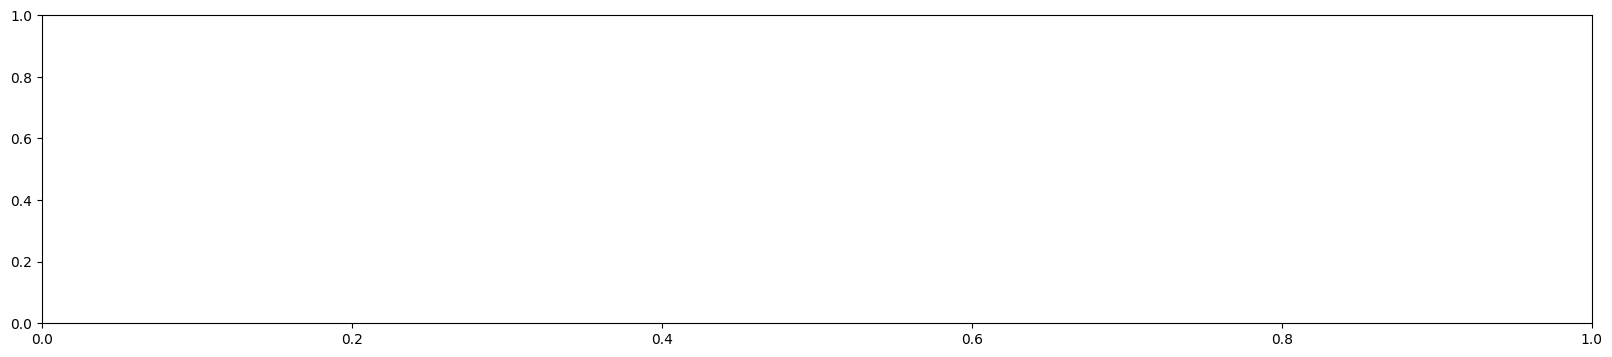

In [ ]:
gmm_setting = {
    ## Gaussian mixture params
    "n_k": 10, #number of ks
    "k_start": 1, # smallest k
    "step_size": 2, # grid space
    "cov_type": "uni_diag", #diag, id or uni_diag, uni_id -- covaraince structure
    "n_mc": 500, #for generating sampling distribution of the quantile estimates
}

kk = [x * gmm_setting['step_size'] + gmm_setting['k_start'] for x in range(1, gmm_setting['n_k']+1)]
q_estimates_gmm = np.empty((gmm_setting['n_k'], gmm_setting['n_mc']))
aic = np.empty(gmm_setting['n_k'])
bic = np.empty(gmm_setting['n_k'])
#test = np.empty(gmm_setting['n_k'])
loglik = np.empty(gmm_setting['n_k'])
for i in range(gmm_setting['n_k']):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    step = gmm_setting['step_size']

    if i == 0:
        mu=None
        sigma=None
        pi= None
    else:
        pi=torch.cat([pi, torch.zeros(step, device=pi.device, dtype=pi.dtype)])
        mu = torch.cat([mu, torch.zeros(step, mu.shape[1], device=mu.device, dtype=mu.dtype)], dim=0)
        sigma = torch.cat([sigma, sigma[0:1].repeat(step, 1)], dim=0)

    mu, sigma, pi = em_gmm_missing(data, M, kk[i], gmm_setting['cov_type'], iters=2000, eps=1e-6, mu=mu, sigma=sigma, pi=pi)

    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, param_vals['n_new']), 0.1) for _ in range(gmm_setting['n_mc'])]
    loglik[i], aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi, gmm_setting['cov_type'])
    print(f"{i} {kk[i]:.2f} {loglik[i]:.2f} {aic[i]:.2f} {bic[i]:.2f}")

# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions)

## Need to adapt this to show the actual true quantile value
truth = np.quantile(data, 0.1)

plt.axhline(y=truth, color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic, color='r', label='AIC')
axs[0].plot(kk, bic, color='b', label='BIC')
axs[0].set_yscale('log')
axs[0].set_xlabel('k: Number of Gaussian components')
axs[0].set_title('AIC/BIC per k')
axs[0].legend()

axs[1].plot(kk, aic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k')
axs[1].set_title('AIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

### scaled identity, different

For scaled idenity cov, we need more components to well approximate the density!

There seems not much difference between using different cov for each component or shared ones in terms of the number of components needed.

In [ ]:
gmm_setting = {
    ## Gaussian mixture params
    "n_k": 10, #number of ks
    "k_start": 0, # smallest k
    "step_size": 40, # grid space
    "cov_type": "id", #diag, id or uni_diag, uni_id -- covaraince structure
    "n_mc": 100, #for generating sampling distribution of the quantile estimates
}

kk = [x * gmm_setting['step_size'] + gmm_setting['k_start'] for x in range(1, gmm_setting['n_k']+1)]
q_estimates_gmm = np.empty((gmm_setting['n_k'], gmm_setting['n_mc']))
aic = np.empty(gmm_setting['n_k'])
bic = np.empty(gmm_setting['n_k'])
loglik = np.empty(gmm_setting['n_k'])
for i in range(gmm_setting['n_k']):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    mu, sigma, pi = em_gmm_missing(data, M, kk[i], gmm_setting['cov_type'], iters=50, eps=1e-6)
    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, param_vals['n_new']), 0.1) for _ in range(gmm_setting['n_mc'])]
    loglik[i], aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi, gmm_setting['cov_type'])

# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions, widths=20)
plt.axhline(y=np.quantile(data, 0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic, color='r', label='AIC')
axs[0].plot(kk, bic, color='b', label='BIC')
axs[0].set_yscale('log')
axs[0].set_xlabel('k: Number of Gaussian components')
axs[0].set_title('AIC/BIC per k')
axs[0].legend()

axs[1].plot(kk, aic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k')
axs[1].set_title('AIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

### scaled idenity, shared

In [ ]:
gmm_setting = {
    ## Gaussian mixture params
    "n_k": 10, #number of ks
    "k_start": 0, # smallest k
    "step_size": 40, # grid space
    "cov_type": "uni_id", #diag, id or uni_diag, uni_id -- covaraince structure
    "n_mc": 100, #for generating sampling distribution of the quantile estimates
}

kk = [x * gmm_setting['step_size'] + gmm_setting['k_start'] for x in range(1, gmm_setting['n_k']+1)]
q_estimates_gmm = np.empty((gmm_setting['n_k'], gmm_setting['n_mc']))
aic = np.empty(gmm_setting['n_k'])
bic = np.empty(gmm_setting['n_k'])
loglik = np.empty(gmm_setting['n_k'])
for i in range(gmm_setting['n_k']):
    data = results['data'][1]['X0']
    M = results['data'][1]['M']
    mu, sigma, pi = em_gmm_missing(data, M, kk[i], gmm_setting['cov_type'], iters=50, eps=1e-6)
    q_estimates_gmm[i]= [np.quantile(sample_gmm(mu, sigma, pi, param_vals['n_new']), 0.1) for _ in range(gmm_setting['n_mc'])]
    loglik[i], aic[i], bic[i] = aic_bic_gmm_missing(data, M, mu, sigma, pi, gmm_setting['cov_type'])

# One boxplot for each row
positions = np.array(kk)
dist = param_vals['distr']

plt.figure(figsize=(20, 4))
plt.boxplot(q_estimates_gmm.T, positions=positions, widths=20)
plt.axhline(y=np.quantile(data, 0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic, color='r', label='AIC')
axs[0].plot(kk, bic, color='b', label='BIC')
axs[0].set_yscale('log')
axs[0].set_xlabel('k: Number of Gaussian components')
axs[0].set_title('AIC/BIC per k')
axs[0].legend()

axs[1].plot(kk, aic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k')
axs[1].set_title('AIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()